# Explore the bee microbiome use case

In [1]:
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
data_dp = Path("../data/use-cases/bee-microbiome/")
data_dp.exists()

result_dp = Path("../results/bee-use-case/")
result_dp.exists()

True

In [3]:
expert_evaluation_fp = data_dp / "expert_evaluation.xlsx"
df_expert = pd.read_excel(expert_evaluation_fp)

# Quick overview
print(f"Rows: {len(df_expert)}")
print(f"Columns: {df_expert.shape[1]}")

Rows: 48
Columns: 22


In [18]:
reps_fp = result_dp / "reps_bee.tsv"
reps_df = pd.read_csv(reps_fp, sep="\t")
# Quick overview
print(f"Rows: {len(reps_df)}")
print(f"Columns: {reps_df.shape[1]}")
reps_df

Rows: 38
Columns: 350


,MAG,Domain,Phylum,Class,Order,Family,Genus,Species,Cluster members,Completeness,...,"kegg_Vancomycin resistance, D-Ala-D-Ser type","kegg_Vibrio cholerae pathogenicity signature, cholera toxins","kegg_Vibrio cholerae pathogenicity signature, toxin coregulated pilus","kegg_Xanthomonas spp. pathogenicity signature, T3SS and effectors","kegg_Xylene degradation, xylene => methylbenzoate","kegg_beta-Carotene biosynthesis, GGAP => beta-carotene","kegg_beta-Lactam resistance, Bla system",kegg_beta-Oxidation,"kegg_beta-Oxidation, acyl-CoA synthesis",kegg_dTDP-L-rhamnose biosynthesis
0,SRR24759608_bin_64934,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia alcalifaciens,2,100.0%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SRR24759606_bin_47167,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia rettgeri_D,1,100.0%,...,NaN,NaN,NaN,6.82,NaN,NaN,NaN,100.00,100.0,83.33
2,SRR24759616_bin_33137,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Proteus,Proteus mirabilis,12,100.0%,...,NaN,NaN,NaN,5.68,NaN,NaN,NaN,100.00,100.0,100.00
3,SRR24759605_bin_35353,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,1,100.0%,...,NaN,NaN,7.14,10.23,NaN,NaN,33.33,100.00,100.0,83.33
4,SRR24759598_bin_98484,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Klebsiella,Klebsiella oxytoca,9,100.0%,...,NaN,NaN,NaN,NaN,33.33,NaN,33.33,100.00,100.0,83.33
5,SRR24759598_bin_132977,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Serratia,Serratia ureilytica,1,100.0%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.00,100.0,83.33
6,SRR24759606_bin_22995,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Entomomonas,unclassified,4,100.0%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.00,100.0,100.00
7,SRR24759603_bin_51590,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Entomomonas,unclassified,3,100.0%,...,NaN,16.67,NaN,NaN,NaN,NaN,NaN,66.67,100.0,100.00
8,SRR24759600_bin_66323,Bacteria,Bacteroidota,Bacteroidia,Flavobacteriales,Weeksellaceae,Apibacter,Apibacter sp945280365,6,99.9%,...,NaN,NaN,NaN,NaN,NaN,NaN,33.33,NaN,100.0,100.00
9,SRR24759612_bin_52183,Bacteria,Bacillota,Bacilli,Bacillales_D,Amphibacillaceae,Virgibacillus,Virgibacillus proomii_B,1,99.8%,...,NaN,NaN,NaN,NaN,NaN,NaN,100.00,100.00,100.0,NaN


# MAGs assigned taxonomy

In [5]:
levels = pd.DataFrame(0, index=["Genus", "Species"], columns=["count", "Species-level MAG count"])

for l in levels.index:
    if l in df_expert.columns:
        levels.loc[l, "count"] = df_expert[l].notna().sum()
        levels.loc[l, "Species-level MAG count"] = df_expert.loc[df_expert[l].notna(), "Species-level MAG count"].sum()
    else:
        print(f"Column '{l}' not found in the DataFrame.")
levels

,count,Species-level MAG count
Genus,38,161
Species,32,148


In [6]:
100*levels.loc["Species","Species-level MAG count"]/levels.loc["Genus","Species-level MAG count"]

np.float64(91.92546583850931)

In [7]:
def get_level_counts(df, level):
    """
    Get counts of non-empty values for a taxonomic level in the DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    level (str): The level to group by in the DataFrame.
    
    Returns:
    pd.DataFrame: A DataFrame with counts and Species-level MAG counts for each level.
    """
    level_group = df.groupby(level)

    # Create count summary
    level_counts = level_group.size().sort_values(ascending=False).to_frame("count")
    level_counts["percentage"] = 100*level_counts["count"] / level_counts["count"].sum()

    # Create MAG count summary
    level_mag_counts = level_group["Species-level MAG count"].sum().sort_values(ascending=False).to_frame("Total MAG count")

    # Merge the two dataframes
    level_summary = pd.concat([level_counts, level_mag_counts], axis=1)
    level_summary.sort_values(by="Total MAG count", ascending=False, inplace=True)

    # Add totals row
    level_summary.loc["TOTAL"] = level_summary.sum(numeric_only=True)
    level_summary.loc["TOTAL", "percentage"] = 100.0  # Percentage for TOTAL should be 100

    return level_summary

display(get_level_counts(df_expert, "Phylum"))
display(get_level_counts(df_expert, "Class"))
display(get_level_counts(df_expert, "Order"))
display(get_level_counts(df_expert, "Family"))
display(get_level_counts(df_expert, "Genus"))
display(get_level_counts(df_expert, "Species"))

,count,percentage,Total MAG count
Phylum,,,
Pseudomonadota,23.0,60.526316,77.0
Bacillota,9.0,23.684211,58.0
Bacillota_A,4.0,10.526316,12.0
Actinomycetota,1.0,2.631579,8.0
Bacteroidota,1.0,2.631579,6.0
TOTAL,38.0,100.000000,161.0


,count,percentage,Total MAG count
Class,,,
Gammaproteobacteria,19.0,50.000000,70.0
Bacilli,9.0,23.684211,58.0
Clostridia,4.0,10.526316,12.0
Actinomycetes,1.0,2.631579,8.0
Alphaproteobacteria,4.0,10.526316,7.0
Bacteroidia,1.0,2.631579,6.0
TOTAL,38.0,100.000000,161.0


,count,percentage,Total MAG count
Order,,,
Lactobacillales,8.0,21.052632,57.0
Enterobacterales,13.0,34.210526,52.0
Lachnospirales,3.0,7.894737,11.0
Pseudomonadales,4.0,10.526316,9.0
Burkholderiales,2.0,5.263158,9.0
Actinomycetales,1.0,2.631579,8.0
Rhizobiales,4.0,10.526316,7.0
Flavobacteriales,1.0,2.631579,6.0
Bacillales_D,1.0,2.631579,1.0


,count,percentage,Total MAG count
Family,,,
Enterobacteriaceae,13.0,34.210526,52.0
Lactobacillaceae,7.0,18.421053,50.0
Lachnospiraceae,3.0,7.894737,11.0
Pseudomonadaceae,4.0,10.526316,9.0
Neisseriaceae,2.0,5.263158,9.0
Bifidobacteriaceae,1.0,2.631579,8.0
Rhizobiaceae,4.0,10.526316,7.0
Enterococcaceae,1.0,2.631579,7.0
Weeksellaceae,1.0,2.631579,6.0


,count,percentage,Total MAG count
Genus,,,
Apilactobacillus,2.0,5.263158,19.0
Frischella,1.0,2.631579,17.0
Fructobacillus,1.0,2.631579,17.0
Proteus,1.0,2.631579,12.0
Lactobacillus,3.0,7.894737,10.0
Novisyntrophococcus,2.0,5.263158,10.0
Klebsiella,1.0,2.631579,9.0
Entomomonas,4.0,10.526316,9.0
Snodgrassella,2.0,5.263158,9.0


,count,percentage,Total MAG count
Species,,,
Frischella perrara,1.0,3.125,17.0
Fructobacillus fructosus,1.0,3.125,17.0
Apilactobacillus kunkeei_C,1.0,3.125,15.0
Proteus mirabilis,1.0,3.125,12.0
Novisyntrophococcus liquoris,1.0,3.125,9.0
Klebsiella oxytoca,1.0,3.125,9.0
Snodgrassella alvi,1.0,3.125,8.0
Bifidobacterium indicum,1.0,3.125,8.0
Enterococcus faecalis,1.0,3.125,7.0


# Comparison of MAGs taxonomy with original study

## Statistics for MAGs origin

In [8]:
origin_df = df_expert["Origin"].value_counts(dropna=False).to_frame("count")
origin_df

,count
Origin,
"Built MAG, Species listed in the paper",19
Built MAG,19
Species listed in the paper,10


In [9]:
print(f"Percentage of species identified by MAGs listed in the paper: {100*origin_df.loc['Built MAG, Species listed in the paper', 'count']/levels.loc['Species', 'count'] if levels.loc['Species', 'count'] > 0 else None}")

Percentage of species identified by MAGs listed in the paper: 59.375


## Species identified by MAGs

### Concordant = corresponding to species listed in the paper 

In [10]:
concordant_mags = df_expert.query("Origin == 'Built MAG, Species listed in the paper' and Species.notna()")
concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
0,SRR24759604_bin_107333,Bacteria,Actinomycetota,Actinomycetes,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium indicum,Bifidobacterium coryneforme,Yes,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper (Figure ?),NaN,8.0,96.81,2.42,1882718.0,0.61
2,SRR24759612_bin_52183,Bacteria,Bacillota,Bacilli,Bacillales_D,Amphibacillaceae,Virgibacillus,Virgibacillus proomii_B,Virgibacillus proomii,Yes,...,"Built MAG, Species listed in the paper",Yes,Non-core,listed in the paper as Virgibacillus proomis (...,NaN,1.0,99.85,0.99,4560752.0,0.36
4,SRR24759605_bin_65734,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus apinorum,Apilactobacillus apinorum,No,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 2),NaN,4.0,75.77,1.20,1054200.0,0.34
5,SRR24759606_bin_54634,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus kunkeei_C,Apilactobacillus kunkeei,Yes,...,"Built MAG, Species listed in the paper",Yes,Non-core,NaN,NaN,15.0,98.66,1.47,1404564.0,0.37
6,SRR24759613_bin_56459,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Bombilactobacillus,Bombilactobacillus mellis,Bombilactobacillus mellis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,4.0,85.51,0.83,1473654.0,0.37
8,SRR24759613_bin_39911,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Fructobacillus,Fructobacillus fructosus,Fructobacillus fructosus,No,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 2),NaN,17.0,97.52,0.23,1276613.0,0.45
9,SRR24759604_bin_148146,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus apis,Lactobacillus apis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,1.0,75.44,2.08,1396370.0,0.37
10,SRR24759603_bin_355,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus helsingborgensis,Lactobacillus helsingborgensis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,6.0,83.57,2.45,1543830.0,0.37
11,SRR24759616_bin_28305,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus melliventris,Lactobacillus melliventris,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,3.0,77.35,3.09,1403520.0,0.36
16,SRR24759613_bin_105744,Bacteria,Bacillota_A,Clostridia,Lachnospirales,Lachnospiraceae,Novisyntrophococcus,Novisyntrophococcus liquoris,Blautia liquoris,Yes,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 4),NaN,9.0,98.77,0.13,3595826.0,0.42


In [11]:
concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,19.000000,19.000000,1.900000e+01
mean,89.672632,1.898421,2.436661e+06
std,10.374308,2.317871,1.258594e+06
min,75.030000,0.050000,1.054200e+06
25%,78.005000,0.220000,1.439109e+06
50%,95.790000,1.200000,2.035396e+06
75%,99.170000,2.435000,3.357385e+06
max,100.000000,9.790000,5.438933e+06


### Non concordant = NOT corresponding to species listed in the paper

In [12]:
non_concordant_mags = df_expert.query("Origin == 'Built MAG' and Species.notna()")
non_concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
3,SRR24759610_bin_19,Bacteria,Bacillota,Bacilli,Lactobacillales,Enterococcaceae,Enterococcus,Enterococcus faecalis,NaN,No,...,Built MAG,NaN,NaN,No mention in the paper,NaN,7.0,99.53,0.39,2744679.0,0.38
17,SRR24759600_bin_132439,Bacteria,Bacillota_A,Clostridia,Tissierellales,Tepidimicrobiaceae,Schnuerera,Schnuerera sp021655095,NaN,Yes,...,Built MAG,NaN,NaN,No mention in the paper.,NaN,1.0,99.64,0.55,2747383.0,0.31
18,SRR24759600_bin_66323,Bacteria,Bacteroidota,Bacteroidia,Flavobacteriales,Weeksellaceae,Apibacter,Apibacter sp945280365,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,6.0,99.89,0.05,2514634.0,0.30
22,SRR24759600_bin_138516,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A choladocola,NaN,Yes,...,Built MAG,NaN,Non-core,NaN,NaN,2.0,87.71,1.61,1731863.0,0.46
23,SRR24759613_bin_38453,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A sp945285915,NaN,Yes,...,Built MAG,NaN,NaN,Correspond to Bartonella api?,NaN,1.0,88.24,1.45,2140910.0,0.42
26,SRR24759605_bin_35353,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,NaN,No,...,Built MAG,NaN,NaN,But Arsenophonus spp listed in the paper,NaN,1.0,99.99,0.70,3251563.0,0.37
30,SRR24759607_bin_27236,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_N,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,78.78,7.15,2195362.0,0.34
31,SRR24759615_bin_55433,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_R,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,75.72,6.96,2390088.0,0.35
33,SRR24759598_bin_119213,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella sp945271295,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,3.0,85.98,0.91,2504613.0,0.34
38,SRR24759602_bin_50685,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia rettgeri,NaN,Yes,...,Built MAG,NaN,NaN,But Providencia spp. listed in the paper,NaN,1.0,87.11,7.31,4418213.0,0.40


In [13]:
non_concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,13.000000,13.000000,1.300000e+01
mean,91.373077,2.381538,2.969065e+06
std,8.858552,2.769485,1.066318e+06
min,75.720000,0.050000,1.731863e+06
25%,85.980000,0.550000,2.246952e+06
50%,88.240000,1.450000,2.514634e+06
75%,99.890000,1.810000,3.251563e+06
max,100.000000,7.310000,5.131086e+06


### Comparison of completess and contamination between concordant and non-concordant species

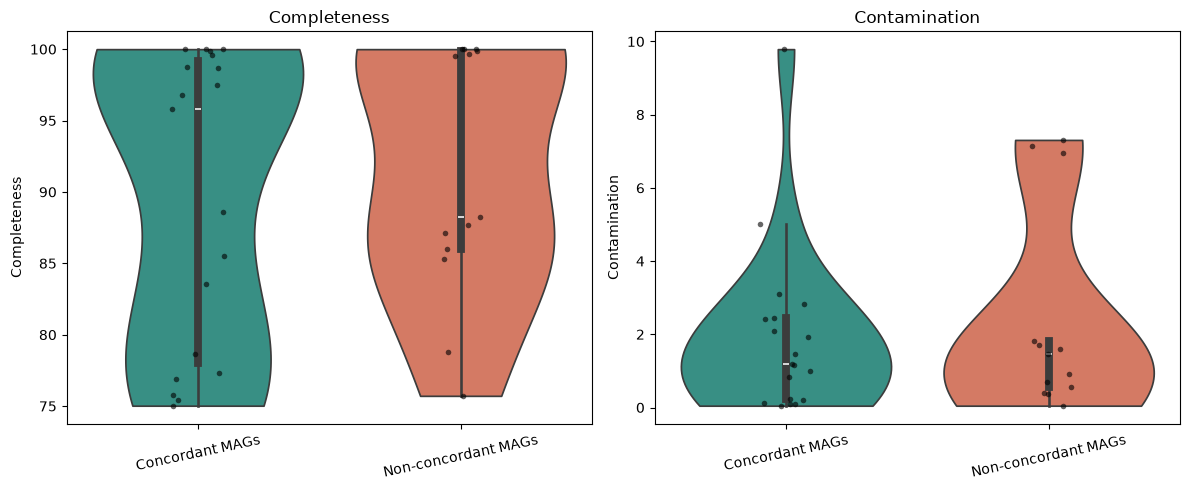

In [14]:
metrics = ["Completeness", "Contamination"]
group_order = ["Concordant MAGs", "Non-concordant MAGs"]

plot_frames = []
for group_name, frame in [
    ("Concordant MAGs", concordant_mags),
    ("Non-concordant MAGs", non_concordant_mags),
]:
    subset = frame[metrics].copy()
    for metric in metrics:
        subset[metric] = pd.to_numeric(subset[metric], errors="coerce")
    subset["Group"] = group_name
    plot_frames.append(subset)

plot_df = pd.concat(plot_frames, ignore_index=True)

palette = {
    "Concordant MAGs": "#2a9d8f",
    "Non-concordant MAGs": "#e76f51",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, metrics):
    sns.violinplot(
        data=plot_df,
        x="Group",
        y=metric,
        hue="Group",
        order=group_order,
        hue_order=group_order,
        palette=palette,
        cut=0,
        inner="box",
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="Group",
        y=metric,
        order=group_order,
        color="black",
        alpha=0.6,
        size=4,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=12)

plt.tight_layout()
plt.show()

# Functional annotations

## Bakta annotations

In [ ]:
bakta_annot_df = reps_df.filter(regex="^bakta_").copy()
bakta_annot_df.columns = bakta_annot_df.columns.str.replace("^bakta_", "", regex=True)
bakta_annot_df.describe()

,CDSs,CRISPR arrays,gaps,hypotheticals,ncRNA regions,ncRNAs,oriCs,oriTs,oriVs,pseudogenes,rRNAs,sORFs,signal peptides,tRNAs,tmRNAs
count,38.000000,38.000000,38.0,38.000000,38.000000,38.000000,38.000000,38.000000,38.0,38.000000,38.000000,38.000000,38.0,38.000000,38.000000
mean,2439.526316,1.263158,0.0,245.131579,19.157895,15.342105,0.552632,0.052632,0.0,13.421053,2.000000,1.210526,0.0,40.000000,0.684211
std,1036.460681,2.101276,0.0,212.441810,13.909993,17.134249,0.645038,0.226294,0.0,13.769594,2.493234,2.672764,0.0,15.502397,0.471069
min,977.000000,0.000000,0.0,42.000000,2.000000,2.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,13.000000,0.000000
25%,1610.750000,0.000000,0.0,81.750000,9.000000,5.000000,0.000000,0.000000,0.0,4.250000,0.000000,0.000000,0.0,30.250000,0.000000
50%,2144.500000,0.000000,0.0,186.000000,14.500000,6.500000,0.000000,0.000000,0.0,8.000000,1.500000,0.000000,0.0,38.500000,1.000000
75%,3090.250000,1.750000,0.0,304.500000,26.750000,21.500000,1.000000,0.000000,0.0,16.000000,3.000000,1.000000,0.0,50.000000,1.000000
max,4991.000000,9.000000,0.0,874.000000,57.000000,73.000000,2.000000,1.000000,0.0,57.000000,13.000000,12.000000,0.0,71.000000,1.000000


## KEGG pathways

In [63]:
kegg_path_df = reps_df.filter(regex="^kegg_").copy()
kegg_path_df.columns = kegg_path_df.columns.str.replace("^kegg_", "", regex=True)
kegg_path_df = kegg_path_df.fillna(0)
print(f"Rows: {kegg_path_df.shape[0]}")
print(f"Columns: {kegg_path_df.shape[1]}")
kegg_path_df = kegg_path_df.loc[:, (kegg_path_df != 0).any(axis=0)]
kegg_path_df = kegg_path_df.loc[(kegg_path_df != 0).any(axis=1), :]
print("After removing rows and columns with all zeros:")
print(f"Rows: {kegg_path_df.shape[0]}")
print(f"Columns: {kegg_path_df.shape[1]}")
kegg_path_df.head(10)

Rows: 38
Columns: 306
After removing rows and columns with all zeros:
Rows: 32
Columns: 301


,3-Hydroxypropionate bi-cycle,"9-membered enediyne core biosynthesis, malonyl-CoA => 3-hydroxyhexadeca-4,6,8,10,12,14-hexaenoyl-ACP => 9-membered enediyne core",ADP-L-glycero-D-manno-heptose biosynthesis,"Acetyl-CoA pathway, CO2 => acetyl-CoA",Acylglycerol degradation,"Adenine ribonucleotide biosynthesis, IMP => ADP,ATP","Adenine ribonucleotide degradation, AMP => Urate","Aerobactin biosynthesis, lysine => aerobactin","Anammox, nitrite + ammonia => nitrogen","Anthranilate degradation, anthranilate => catechol",...,"Vancomycin resistance, D-Ala-D-Ser type","Vibrio cholerae pathogenicity signature, cholera toxins","Vibrio cholerae pathogenicity signature, toxin coregulated pilus","Xanthomonas spp. pathogenicity signature, T3SS and effectors","Xylene degradation, xylene => methylbenzoate","beta-Carotene biosynthesis, GGAP => beta-carotene","beta-Lactam resistance, Bla system",beta-Oxidation,"beta-Oxidation, acyl-CoA synthesis",dTDP-L-rhamnose biosynthesis
1,16.67,0.00,100.0,0.0,0.0,100.0,66.67,0.0,0.0,25.00,...,0.0,0.00,0.00,6.82,0.00,0.0,0.00,100.00,100.0,83.33
2,16.67,0.00,100.0,0.0,50.0,100.0,66.67,25.0,0.0,0.00,...,0.0,0.00,0.00,5.68,0.00,0.0,0.00,100.00,100.0,100.00
3,16.67,0.00,100.0,0.0,50.0,100.0,100.00,25.0,0.0,0.00,...,0.0,0.00,7.14,10.23,0.00,0.0,33.33,100.00,100.0,83.33
4,22.22,0.00,100.0,0.0,0.0,100.0,66.67,0.0,0.0,25.00,...,0.0,0.00,0.00,0.00,33.33,0.0,33.33,100.00,100.0,83.33
5,16.67,0.00,100.0,0.0,0.0,100.0,66.67,25.0,0.0,33.33,...,0.0,0.00,0.00,0.00,0.00,0.0,0.00,100.00,100.0,83.33
6,16.67,0.00,80.0,0.0,50.0,100.0,66.67,0.0,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,0.00,100.00,100.0,100.00
7,16.67,0.00,80.0,0.0,50.0,100.0,66.67,0.0,0.0,0.00,...,0.0,16.67,0.00,0.00,0.00,0.0,0.00,66.67,100.0,100.00
8,16.67,0.00,0.0,0.0,0.0,100.0,66.67,0.0,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,33.33,0.00,100.0,100.00
9,22.22,6.25,60.0,0.0,50.0,100.0,66.67,0.0,0.0,0.00,...,0.0,0.00,0.00,0.00,0.00,0.0,100.00,100.00,100.0,0.00
10,11.11,0.00,0.0,0.0,0.0,50.0,77.78,0.0,0.0,0.00,...,0.0,0.00,0.00,1.14,0.00,0.0,33.33,0.00,0.0,33.33


In [49]:
# Count how many KEGG pathways reach a given completeness threshold for each MAG
thresholds = [50, 75, 100]
kegg_path_counts_df = pd.DataFrame(index=kegg_path_df.index)

for threshold in thresholds:
    kegg_path_counts_df[f"pathways with completeness >= {threshold}%"] = (kegg_path_df >= threshold).sum(axis=1)

kegg_path_counts_df = kegg_path_counts_df.sort_values(by="pathways with completeness >= 50%", ascending=False)
kegg_path_counts_df.describe()

,pathways with completeness >= 50%,pathways with completeness >= 75%,pathways with completeness >= 100%
count,32.000000,32.00000,32.000000
mean,96.593750,58.78125,40.312500
std,37.268736,27.51508,23.647188
min,31.000000,10.00000,5.000000
25%,73.500000,41.50000,24.500000
50%,94.500000,56.50000,37.000000
75%,122.500000,79.25000,52.000000
max,171.000000,116.00000,98.000000


In [ ]:
# Count in how many MAGs a KEGG pathway reaches a given completeness threshold
kegg_pathway_mag_counts_df = pd.DataFrame(index=kegg_path_df.columns)

for threshold in thresholds:
    kegg_pathway_mag_counts_df[f"MAGs with completness >= {threshold}%"] = (kegg_path_df >= threshold).sum(axis=0)

kegg_pathway_mag_counts_df = kegg_pathway_mag_counts_df.sort_values(by="MAGs with completness >= 50%", ascending=False)
kegg_pathway_mag_counts_df

,MAGs with completness >= 50%,MAGs with completness >= 75%,MAGs with completness >= 100%
"Guanine ribonucleotide biosynthesis, IMP => GDP,GTP",32,29,17
"Nucleotide sugar biosynthesis, glucose => UDP-glucose",32,18,18
"Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate",32,27,13
"C1-unit interconversion, prokaryotes",32,14,14
Pentose phosphate pathway (Pentose phosphate cycle),32,23,12
...,...,...,...
"Pyocyanine biosynthesis, chorismate => pyocyanine",0,0,0
Hydroxypropionate-hydroxybutylate cycle,0,0,0
"Incomplete reductive citrate cycle, acetyl-CoA => oxoglutarate",0,0,0
"Inositol phosphate metabolism, Ins(1,3,4,5)P4 => Ins(1,3,4)P3 => myo-inositol",0,0,0


In [66]:
print(f"Number of pathways with completeness < 50% in all MAG: {((kegg_path_df < 50).all(axis=0)).sum()}")
print(f"Number of pathways with completeness < 75% in all MAG: {((kegg_path_df < 75).all(axis=0)).sum()}")
print(f"Number of pathways with completeness >= 50 % in all MAG: {((kegg_path_df >= 50).all(axis=0)).sum()}")
print(f"Number of pathways with completeness >= 75 % in all MAG: {((kegg_path_df >= 75).all(axis=0)).sum()}")


Number of pathways with completeness < 50% in all MAG: 90
Number of pathways with completeness < 75% in all MAG: 144
Number of pathways with completeness >= 50 % in all MAG: 6
Number of pathways with completeness >= 75 % in all MAG: 0


In [68]:
kegg_pathway_mag_counts_df.index[kegg_pathway_mag_counts_df.iloc[:, 0].eq(32)].tolist()

['Guanine ribonucleotide biosynthesis, IMP => GDP,GTP',
 'Nucleotide sugar biosynthesis, glucose => UDP-glucose',
 'Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate',
 'C1-unit interconversion, prokaryotes',
 'Pentose phosphate pathway (Pentose phosphate cycle)',
 'F-type ATPase, prokaryotes and chloroplasts']